Finding boulders that were rated highly specifically by women



1.   API call to Mountain Project for boulders in a specific region

2.   For each boulder problem, pull out the user stars, ticks, and grade ratings. 

3.   Combine the above dataframes into one that includes all of the information for that boulder problem. 

4.   Once that has been completed, repeat for all boulder problems. 

5.   Use the combined dataframe for all boulder problems to find the user ID and name of all unique relevant users. 

6.   Pull the user data and make a user personal information database. 

7.   Combine the boulder problem database wtih the user information database. 

8.   Now all of the data is processed together, so I can start analyzing it. 

* How much information do I have on users? How many are missing data, etc
* How well am I guessing the gender of users?  I think the guesser is biased towards names of European descent.
* For each boulder problem, Display rating for overall, male, female, undetermined. 
* Also pull out dataframe of comments from women.
* Do I want to use AI to guess user gender from their comments attached to their ticks?





In [116]:
# Import packages
from bs4 import BeautifulSoup # https://beautiful-soup-4.readthedocs.io/en/latest/
import copy
from datetime import datetime
import gender_guesser.detector as gender
import io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import requests # https://requests.readthedocs.io/en/latest/
import time
import urllib.parse


In [122]:
# Define functions


def retrieve_overview_csv(URL):
  """
  This function is designed to work with the output of "Route Finder" on 
  Mountain Project. The URL corresponds to the Mountain project page that has
  a "Export CSV" button at the top. 

  Args:
      URL: This is the URL of the webpage. Type is string. 

  Returns:
      return_type: pandas dataframe
  """

  csv_export_request = requests.get(URL)

  if csv_export_request.status_code == 200:
    csv_df = pd.read_csv(io.StringIO(csv_export_request.text))
    print("CSV converted to pandas df")
  else:
    print("Something went wrong. Status code is: " + str(csv_export_request.status_code))


  csv_df[['Route Grade', 'Route Danger Rating']] = csv_df['Rating'].str.split(' ', expand=True)

  return csv_df


def get_route_URL(URL):
  """
  This function takes the URL of a specific climb and converts it to the URL 
  for the climbing statistics page. 

  Args:
      URL: This is the URL to the Mountain Project page for this climb. The type
      is string. 
      

  Returns:
      return_type: This is the URL to the Mountain Project stats page for this 
      climb. The type is string.  
  """

  substring = "/route/"
  text_to_insert = "stats/"
  return URL.replace(substring, substring + text_to_insert)



def get_route_stats(URL, stat_type, params = {'per_page': '250','page': '1',}, retries = 3, backoff = 2):
  """
  This function takes the URL of a specific climb and converts it to the URL 
  used to request the specified table on the route stats page.  

  Args:
      URL: This is the URL to the Mountain Project page for this climb. The type
           is string. 
      stat_type: This is the stat type that is requested. 
      params: Dictionary of parameters for the requested data. Default setting 
              is the default setting from MountainProject.
      

  Returns:
      return_type: This is a pandas dataframe of the requested route stat info.
      The type is pandas dataframe.  
  """
  prefix = "https://www.mountainproject.com/api/v2/routes/"
  
  if stat_type in ['stars', 'ratings', 'ticks', 'todos']:
    req_URL = prefix + URL.split('/')[-2] + "/" + stat_type
    wait = backoff
    for attempt in range(retries):
      response = requests.get(req_URL, params=params, headers=HEADERS)
      if response.status_code == 200 and response.text.strip():
        return pd.json_normalize(response.json()['data'])
      print(f"Attempt {attempt + 1} failed ({response.status_code}) for {req_URL}, retrying in {wait}s...")
      time.sleep(wait)
      wait *= 2
    print(f"All {retries} attempts failed for {req_URL}. Returning empty DataFrame.")
    return pd.DataFrame()

  else:
    print("This is not an accepted stat_type request.\
          \nTry 'stars', 'ratings', 'ticks', or 'todos'.")
    return pd.DataFrame()
  


def create_route_stats_df(route_name, star_df, rating_df, tick_df, prefix_col = ['id', 'date', 'createdAt', 'updatedAt']):
  """
  This function is designed to work with function fill_area_df_with_stats. It takes as input
  the individual stats dataframes for the specificed route, adds prefix's to unique columns that 
  share names across dataframes and performs a merge to create a dataframe that includes all of
  the stats. 


  Args:
      route_name: This is the name of the route, as listed on Mountain Project. Type is string.
      star_df: This is the dataframe of the star stats for this route. Type is pandas dataframe. 
      rating_df: This is the dataframe of the difficulty ratings for this route. Type is pandas dataframe.
      tick_df: This is the dataframe of user ticks and comments for this route. Type is pandas dataframe.
      prefix_col:   This is the list of columns that need a prefix indicating what stat dataframe this column
                    is affiliated with before the stat dataframes are merged together.


  Returns:
      return_type:  pandas dataframe. This is the combined stats for an individual climbing
                    route. route_stas_df.
  """ 
  # Prepare star_df for merge
  star_df.columns = [f'star_{i}' if i in prefix_col else f'{i}' for i in star_df.columns]

  # Prepare rating_df for merge
  cols_to_drop = rating_df.columns[(rating_df == 0).all()]
  rating_df.drop(columns=cols_to_drop, inplace = True)
  rating_df.columns = [f'rating_{i}' if i in prefix_col else f'{i}' for i in rating_df.columns]

  # Prepare tick_df for merge
  if 'user.id' in tick_df.columns:
    tick_df.dropna(subset=['user.id'], inplace = True)
    tick_df['user.id'] = tick_df['user.id'].astype('Int64')
  if 'comment' in tick_df.columns:
    #tick_df['comment'] = tick_df['text'].str.split(".", n = 1, expand = True).iloc[:, 1:]
    tick_df['comment'] = tick_df['text'].str.split(".", n = 1, expand = True).get(1)
  cols_to_drop = ['user', 'text']
  for item in cols_to_drop[:]:
    if item not in tick_df.columns:
      cols_to_drop.remove(item)
  if cols_to_drop != []:
    tick_df.drop(columns=cols_to_drop, inplace = True)
  tick_df.columns = [f'tick_{i}' if i in prefix_col else f'{i}' for i in tick_df.columns]


  # merge with csv_df (aka overall route df)
  # Ensure empty DataFrames have at least the shared join columns so merge doesn't fail
  for df in [star_df, rating_df, tick_df]:
    for col in ['user.id', 'user.name']:
      if col not in df.columns:
        df[col] = pd.Series(dtype='object')
  route_stats_df = star_df.merge(rating_df, how = 'outer').merge(tick_df, how = 'outer')
  route_stats_df['user.id'] = route_stats_df['user.id'].astype('Int64')
  route_stats_df['Route'] = route_name

  return route_stats_df


def fill_area_df_with_stats(area_df, cache_path='route_stats_cache.pkl', delay=0.5, retries=3, backoff=2):
  """
  This function takes the overview pandas dataframe of a climbing area (the output of retrieve_overview_csv)
  and performs a request for each climbing route to retrieve the stats regarding stars, ratings, and ticks 
  for that route using the get_route_stats function. Once stats for all routes have been retrieved, they 
  are merged with the area overview dataframe and this resulting dataframe is returned. 

  Results are cached to disk after each route so that progress is preserved if the function is interrupted.
  On re-run, already-fetched routes are skipped.

  Args:
      area_df:    Type is pandas dataframe. Overview of the climbing area as downloaded from Mountain project
                  using function retrieve_overview_csv. 
      cache_path: Path to the pickle file used to cache results between runs. Default is 'route_stats_cache.pkl'.
      delay:      Seconds to wait between API calls. Default is 0.5.
      retries:    Number of retry attempts in get_route_stats on failure. Default is 3.
      backoff:    Initial wait time in seconds between retries (doubles each attempt). Default is 2.

  Returns:
      return_type:  Pandas dataframe. This is the original input dataframe, now merged
                    with stats(stars, ratings, and ticks) of each route.  
  """
  route_dict = {}
  for i in range(0, len(area_df)):
      route_dict.update({area_df.iat[i,0]: get_route_URL(area_df.iat[i,2])})
  print(route_dict)

  # Load from cache if available, otherwise start fresh
  if os.path.exists(cache_path):
      all_routes_stats_df = pd.read_pickle(cache_path)
      completed_routes = set(all_routes_stats_df['Route'].unique())
      print(f"Resuming — {len(completed_routes)} routes already cached.")
  else:
      all_routes_stats_df = pd.DataFrame(columns = ['star_id', 'score', 'star_createdAt', 'star_updatedAt', 'user.id',
                                                    'user.name', 'rating_id', 'allRatings', 'boulderRating', 'safteyRating',
                                                    'rating_createdAt', 'rating_updatedAt', 'tick_id', 'tick_date',
                                                    'comment', 'style', 'leadStyle', 'pitches', 'tick_createdAt',
                                                    'tick_updatedAt', 'Route']).astype({'user.id': 'Int64'})
      completed_routes = set()

  for keys in route_dict.keys():
      if keys in completed_routes:
          print(f"Skipping '{keys}' (already cached)")
          continue
      print('starting on ' + keys)
      star_df = get_route_stats(URL = route_dict[keys], stat_type = "stars", params = {'per_page': '250','page': '1'}, retries=retries, backoff=backoff)
      print('made star_df')
      time.sleep(delay)
      rating_df = get_route_stats(URL = route_dict[keys], stat_type = 'ratings', params = {'per_page': '250','page': '1'}, retries=retries, backoff=backoff)
      print('made rating_df')
      time.sleep(delay)
      tick_df = get_route_stats(URL = route_dict[keys], stat_type = 'ticks', params = {'per_page': '250','page': '1'}, retries=retries, backoff=backoff)
      print('made tick_df')
      route_stats_df = create_route_stats_df(route_name = keys, 
                                             star_df = star_df, 
                                             rating_df = rating_df, 
                                             tick_df= tick_df, 
                                             prefix_col = ['id', 'date', 'createdAt', 'updatedAt'])
      print("made route_stats_df")
      all_routes_stats_df = pd.concat([all_routes_stats_df, route_stats_df])
      all_routes_stats_df.to_pickle(cache_path)
      print("Finished updating all_routes_stats_df with stats from " + route_dict[keys])
  return all_routes_stats_df
 


      
    
  


def user_apply_func(x):
    '''
    This functions is designed to apply row-by-row to a pandas dataframe. 
    It takes as input the dataframe of all relevant users (listing their user ID and username) and initiates the individual user dicitonary.
    '''
    # initiate dictionary
    user_dict = dict.fromkeys(['user_ID', 'user_name', 'user_URL', 'request_date', 'location', 'age_at_request_date', 'listed_gender', 'guessed_gender'])
    # fill the dictionary values
    user_dict['user_ID'] = x['user.id']
    user_dict['user_name'] = x['user.name']
    return user_dict


# Probably don't need this...
# def compile_all_user_dict(star_df, rating_df, tick_df, shared_col = ['user.id', 'user.name']):
#   """
#     This function takes the combined data frame (?) or list of relevant data frames(?)
#     and makes a list(?) of all of the user names/user IDs. Probably make dictionary
#     of user ID as key and a nested dictionary of ID and name.  

#     Args:
#         star_df: 
#         rating_df
#         tick_df
#         shared_col
        

#     Returns:
#         return_type: This is a nested dictionary of user IDs as top level keys 
#         and user names and other information as nested keys. 
#   """
  
#   unique_user_df = star_df.merge(rating_df, how = 'outer', on = shared_col).merge(tick_df, how = 'outer', on = shared_col)[shared_col].dropna().drop_duplicates()

#   unique_user_df['user.id'] = unique_user_df['user.id'].astype(int)

#   unique_user_df['user_dict'] = unique_user_df.apply(user_apply_func, axis = 1)

#   unique_user_df.set_index('user.id', inplace = True)
#   all_user_dict = unique_user_df[['user_dict']].iloc[:, 0].to_dict()
#   return all_user_dict

  
  



def get_user_info(user_dict, retries=3, backoff=2):
  """
  This function takes the dictionary of an individual user, containing their
  user ID and name. It returns the dictionary of an individual user updated with
  the age of the user at time of request, the date of data request, the 
  user's gender, and the user's location of residence. 


  Args:
      user_dict:
      

  Returns:
      return_type: a dictionary of user information. 
      {user_ID, user_name, listed_gender, guessed_gender, age_at_request_date, 
       request_date, location}
  """

  # user_dict['user_ID'] = "201730853"
  # user_dict['user_name'] = "Corey Stegall"

  user_dict['user_URL'] = "https://www.mountainproject.com/user/" + str(user_dict['user_ID']) + "/" + urllib.parse.quote(user_dict['user_name'].lower().replace(" ", "-"))


  # page = requests.get(user_dict['user_URL']) # Step 1: get the page content
  # soup = BeautifulSoup(page.text, 'html.parser')
  wait = backoff
  for attempt in range(retries):
      try:
          page = requests.get(user_dict['user_URL'], headers=HEADERS)
          break
      except requests.exceptions.ConnectionError as e:
          print(f"Attempt {attempt + 1} failed for{user_dict['user_URL']}: {e}")
          if attempt + 1 == retries:
              print("All retries failed, skipping user.")
              return user_dict
          time.sleep(wait)
          wait *= 2
  soup = BeautifulSoup(page.text, 'html.parser')



  lines = soup.find_all("div", class_ = "")

  line_list = []
  for line in lines:
    if line.get_text().strip() != '':
      line_list.append(line.get_text().strip())

  #print(line_list)


  if len(line_list) > 0:
    line_list = line_list[0].replace("  ", "").split('\n')
    print(user_dict['user_name'] + ": line_list exists")
  else:
    print(user_dict['user_name'] + ": line_list is empty")

  #print(line_list)


  for i in range(0, len(line_list)):
    if len(line_list[i]) < 3:
      continue
    elif "years old" in line_list[i]:
      user_dict['age_at_request_date'] = int(line_list[i].split()[0])
    elif line_list[i] in ('Male', 'Female'):
      user_dict['listed_gender'] = line_list[i]
    else:
      user_dict['location'] = line_list[i]

    user_dict['request_date'] = datetime.now().year


    
  user_dict["guessed_gender"] = gender.Detector().get_gender(user_dict['user_name'].split(" ")[0].title())




  return user_dict


def fill_user_dict_with_info(all_user_dict, cache_path='user_info_cache.pkl', delay=2):
      # Load cache if available
      if os.path.exists(cache_path):
          with open(cache_path, 'rb') as f:
              cached_dict = pickle.load(f)
          completed_ids = set(cached_dict.keys())
          # Merge cached entries back into all_user_dict
          for k, v in cached_dict.items():
              if k in all_user_dict:
                  all_user_dict[k] = v
          print(f"Resuming — {len(completed_ids)} users already cached.")
      else:
          completed_ids = set()

      for key in all_user_dict.keys():
          if key in completed_ids:
              print(f"Skipping user {key} (already cached)")
              continue
          get_user_info(user_dict=all_user_dict[key])
          time.sleep(delay)
          # Save after each user
          with open(cache_path, 'wb') as f:
              pickle.dump(all_user_dict, f)

      return all_user_dict



def remove_failed_users_from_cache(cache_path='user_info_cache.pkl', dry_run=False):
    """
    Removes entries from the user info cache where data retrieval failed
    (i.e., request_date is None). This allows fill_user_dict_with_info to
    retry those users on the next run.

    Args:
        cache_path: Path to the user info cache pickle file. Default is 'user_info_cache.pkl'.
        dry_run:    If True, print what would be removed without modifying the cache. Default is False.

    Returns:
        removed_ids: List of user IDs that were (or would be) removed.
    """
    if not os.path.exists(cache_path):
        print(f"Cache file '{cache_path}' not found.")
        return []

    with open(cache_path, 'rb') as f:
        cache = pickle.load(f)

    failed_ids = [uid for uid, info in cache.items() if info.get('request_date') is None]

    if not failed_ids:
        print("No failed entries found in cache.")
        return []

    print(f"Found {len(failed_ids)} failed entries (request_date is None).")

    if dry_run:
        print("Dry run — no changes made. Failed user IDs:")
        for uid in failed_ids:
            print(f"  {uid}: {cache[uid].get('user_name')}")
        return failed_ids

    for uid in failed_ids:
        del cache[uid]

    with open(cache_path, 'wb') as f:
        pickle.dump(cache, f)

    print(f"Removed {len(failed_ids)} failed entries from cache. They will be retried on next run.")
    return failed_ids

def fill_missing_guessed_gender(user_info_df):
    """
    For any row in user_info_df where guessed_gender is NA, infers the gender
    from the first word of user_name using gender_guesser and fills it in.

    Args:
        user_info_df: DataFrame with at least 'user_name' and 'guessed_gender' columns.

    Returns:
        user_info_df with guessed_gender filled in where it was NA.
    """
    detector = gender.Detector()
    mask = user_info_df['guessed_gender'].isna()
    user_info_df.loc[mask, 'guessed_gender'] = user_info_df.loc[mask, 'user_name'].apply(
        lambda name: detector.get_gender(str(name).split(" ")[0].title())
    )
    print(f"Filled guessed_gender for {mask.sum()} rows.")
    return user_info_df

In [118]:
# set variable values

HEADERS = {'User-Agent': 'Independent research project - contact: carlybond907@gmail.com'}

# Go to Mountain Project and navigate to climbing area of interest. Open the Find routes button and filter for all routes of interest. 
# In the original use case, filter for all boulder problems. 
URL = "https://www.mountainproject.com/route-finder-export?diffMaxaid=75260&diffMaxboulder=21700&diffMaxice=38500&diffMaxmixed=65050&diffMaxrock=5500&diffMinaid=70000&diffMinboulder=20000&diffMinice=30000&diffMinmixed=50000&diffMinrock=1800&is_sport_climb=1&is_top_rope=1&is_trad_climb=1&pitches=0&selectedIds=105716862&sort1=area&sort2=rating&stars=0&type=boulder&viewAll=1"



In [ ]:
csv_df = retrieve_overview_csv(URL)

In [60]:
csv_df.to_csv("20260329_Big_Bend_Bouldering_overview.csv", index = False)

In [61]:
all_routes_stats_df = fill_area_df_with_stats(area_df = csv_df)

{'Death Flakes': 'https://www.mountainproject.com/route/stats/114444130/death-flakes', 'Rampage': 'https://www.mountainproject.com/route/stats/106135567/rampage', 'Press tight': 'https://www.mountainproject.com/route/stats/112359419/press-tight', 'The Grim Reacher': 'https://www.mountainproject.com/route/stats/106135578/the-grim-reacher', 'Circus Trick': 'https://www.mountainproject.com/route/stats/105717433/circus-trick', 'Circus Trick Right': 'https://www.mountainproject.com/route/stats/106127755/circus-trick-right', 'Chaos': 'https://www.mountainproject.com/route/stats/106013793/chaos', 'Hell Belly Stand': 'https://www.mountainproject.com/route/stats/107957139/hell-belly-stand', 'Grim Reacher Direct': 'https://www.mountainproject.com/route/stats/109990646/grim-reacher-direct', 'Phantom Fighter (Stand)': 'https://www.mountainproject.com/route/stats/109990741/phantom-fighter-stand', 'Hell Belly': 'https://www.mountainproject.com/route/stats/106379808/hell-belly', 'Phantom Fighter': 'h

/tmp/ipykernel_36548/414128257.py:209: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_routes_stats_df = pd.concat([all_routes_stats_df, route_stats_df])


made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/106135567/rampage
starting on Press tight
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/112359419/press-tight
starting on The Grim Reacher
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/106135578/the-grim-reacher
starting on Circus Trick
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/105717433/circus-trick
starting on Circus Trick Right
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/106127

In [62]:
all_routes_stats_df

,star_id,score,star_createdAt,star_updatedAt,user.id,user.name,rating_id,allRatings,boulderRating,safteyRating,...,rating_updatedAt,tick_id,tick_date,comment,style,leadStyle,pitches,tick_createdAt,tick_updatedAt,Route
0,NaN,NaN,NaN,NaN,10795,Craig Quincy,NaN,NaN,NaN,NaN,...,NaN,200741538.0,"Apr 8, 2025, 12:00 am",None,,,1.0,2025-04-09T04:29:09.000000Z,2025-04-09T04:29:09.000000Z,Death Flakes
1,NaN,NaN,NaN,NaN,10795,Craig Quincy,NaN,NaN,NaN,NaN,...,NaN,123957986.0,"Apr 2, 2023, 12:00 am",Half way,Attempt,,1.0,2023-04-02T23:11:53.000000Z,2023-04-02T23:11:53.000000Z,Death Flakes
2,36863921.0,4.0,2021-03-31T00:58:00.000000Z,2021-03-31T00:58:00.000000Z,105841142,kzoo,NaN,NaN,NaN,NaN,...,NaN,120465382.0,"Mar 30, 2021, 12:00 am",,Lead,Onsight,1.0,2021-03-31T00:57:57.000000Z,2021-03-31T00:57:57.000000Z,Death Flakes
3,22621623.0,4.0,2019-05-16T18:55:11.000000Z,2019-05-16T18:55:11.000000Z,106196136,Ivano Del Piccolo,NaN,NaN,NaN,NaN,...,NaN,116981808.0,"May 16, 2019, 12:00 am",None,,,1.0,2019-05-16T18:55:03.000000Z,2019-05-16T18:55:03.000000Z,Death Flakes
4,46197554.0,4.0,2022-01-18T01:23:33.000000Z,2022-01-18T01:23:33.000000Z,106201630,ben jammin,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Death Flakes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,NaN,NaN,NaN,NaN,201037780,Harrison Arthur,NaN,NaN,NaN,NaN,...,NaN,202024780.0,"Oct 29, 2025, 12:00 am","LH lower flake, RH same side pull to add an e...",Send,,1.0,2025-11-04T03:13:07.000000Z,2025-11-04T03:13:07.000000Z,Gummy Bear Ninja Wizard Turtle Penguin Cyclopes
3,112712472.0,4.0,2025-03-31T22:39:05.000000Z,2025-03-31T22:39:05.000000Z,201777038,Wyatt Murphy,NaN,NaN,NaN,NaN,...,NaN,200705267.0,"Mar 31, 2025, 12:00 am",,Send,,1.0,2025-03-31T22:39:04.000000Z,2025-03-31T22:39:04.000000Z,Gummy Bear Ninja Wizard Turtle Penguin Cyclopes
0,130496336.0,3.0,2025-11-16T22:14:50.000000Z,2025-11-16T22:14:50.000000Z,108809388,Marcus St Jolie,2777087.0,[V4],20400.0,,...,2025-11-16T22:14:50.000000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sunken Ship
1,112151754.0,4.0,2025-03-23T19:59:40.000000Z,2025-03-23T19:59:40.000000Z,200918621,Shaylor Jack,2675618.0,[V6],20600.0,,...,2025-03-23T19:59:40.000000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sunken Ship


In [63]:

area_df = csv_df.merge(all_routes_stats_df, how = 'left')
area_df['user.id'] = area_df['user.id'].astype('Int64')

In [ ]:
area_df.to_csv("20260329_area_df_with_stats.csv", index = False)

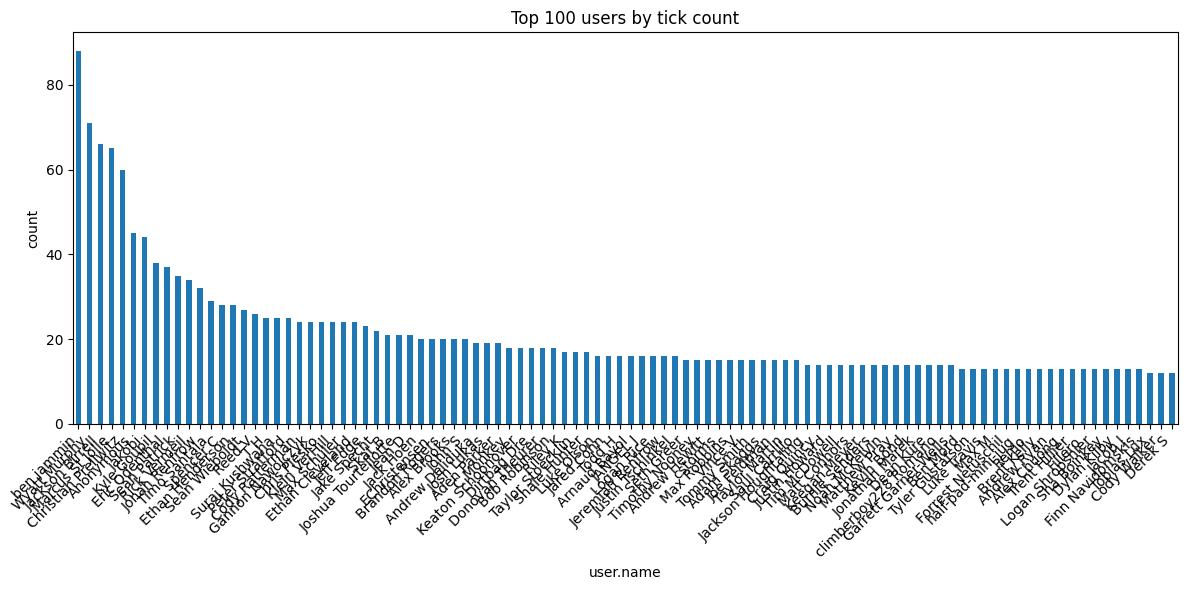

Total unique users: 1998
user.name
ben jammin             88
Wyatt Murphy           71
Jackson Birrell        66
Marcus St Jolie        65
Christian Prellwitz    60
Anonymous              45
jakobi                 44
Kyle Goupil            38
Eric Odenthal          37
Sean Patrick           35
Name: count, dtype: int64


In [65]:




vc = area_df['user.name'].value_counts()
top_n = 100

fig, ax = plt.subplots(figsize=(12, 6))
vc.head(top_n).plot(kind='bar', ax=ax)
ax.set_title(f'Top {top_n} users by tick count')
ax.set_xlabel('user.name')
ax.set_ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique users: {vc.shape[0]}')
print(vc.head(10))

In [84]:
unique_user_df = (
    area_df[['user.id', 'user.name']]
    .dropna()
    .drop_duplicates()
    .copy()
)
unique_user_df['user.id'] = unique_user_df['user.id'].astype(int)
unique_user_df['user_dict'] = unique_user_df.apply(user_apply_func, axis=1)
unique_user_df.set_index('user.id', inplace=True)
all_user_dict = unique_user_df['user_dict'].to_dict()

print(f"Unique users found: {len(all_user_dict)}")

Unique users found: 2029


In [89]:
# for key in all_user_dict.keys():
#     get_user_info(user_dict=all_user_dict[key])

all_user_dict = fill_user_dict_with_info(all_user_dict)

Resuming — 2029 users already cached.
Skipping user 10795 (already cached)
Skipping user 105841142 (already cached)
Skipping user 106196136 (already cached)
Skipping user 106201630 (already cached)
Skipping user 106484139 (already cached)
Skipping user 106646308 (already cached)
Skipping user 106709875 (already cached)
Skipping user 106827872 (already cached)
Skipping user 106839278 (already cached)
Skipping user 106899065 (already cached)
Skipping user 107102487 (already cached)
Skipping user 107147681 (already cached)
Skipping user 107798616 (already cached)
Skipping user 108809388 (already cached)
Skipping user 109227367 (already cached)
Skipping user 109520650 (already cached)
Skipping user 109527937 (already cached)
Skipping user 110698353 (already cached)
Skipping user 110708951 (already cached)
Skipping user 110752881 (already cached)
Skipping user 110869349 (already cached)
Skipping user 110944243 (already cached)
Skipping user 110966666 (already cached)
Skipping user 111129685

In [119]:
#  if os.path.exists('user_info_cache.pkl'):
#       os.remove('user_info_cache.pkl')
#       print("Deleted corrupted cache.")


# remove_failed_users_from_cache(dry_run=False)

all_user_dict = fill_user_dict_with_info(all_user_dict)


Resuming — 611 users already cached.
Skipping user 10795 (already cached)
Skipping user 105841142 (already cached)
Ivano Del Piccolo: line_list is empty
Skipping user 106201630 (already cached)
Skipping user 106484139 (already cached)
kiff: line_list is empty
Skipping user 106709875 (already cached)
Skipping user 106827872 (already cached)
Skipping user 106839278 (already cached)
Skipping user 106899065 (already cached)
Skipping user 107102487 (already cached)
Skipping user 107147681 (already cached)
Skipping user 107798616 (already cached)
Skipping user 108809388 (already cached)
Skipping user 109227367 (already cached)
Skipping user 109520650 (already cached)
Skipping user 109527937 (already cached)
Skipping user 110698353 (already cached)
Skipping user 110708951 (already cached)
Skipping user 110752881 (already cached)
Skipping user 110869349 (already cached)
Skipping user 110944243 (already cached)
Skipping user 110966666 (already cached)
Skipping user 111129685 (already cached)
Sk

KeyboardInterrupt: 

In [124]:
user_info_df = fill_missing_guessed_gender(user_info_df)

Filled guessed_gender for 0 rows.


In [92]:
user_info_df = pd.DataFrame(all_user_dict.values())
print(user_info_df.shape)
user_info_df.head()

(2029, 8)


,user_ID,user_name,user_URL,request_date,location,age_at_request_date,listed_gender,guessed_gender
0,10795,Craig Quincy,https://www.mountainproject.com/user/10795/cra...,2026.0,"Louisville, CO",NaN,Male,male
1,105841142,kzoo,https://www.mountainproject.com/user/105841142...,2026.0,michigan,48.0,Male,unknown
2,106196136,Ivano Del Piccolo,https://www.mountainproject.com/user/106196136...,NaN,None,NaN,None,male
3,106201630,ben jammin,https://www.mountainproject.com/user/106201630...,2026.0,"Moab, UT",41.0,Male,male
4,106484139,Brian Koralewski,https://www.mountainproject.com/user/106484139...,2026.0,"Springville, UT",NaN,Male,male


In [ ]:
#user_info_df.to_csv("20260329_user_info_df.csv", index = False)

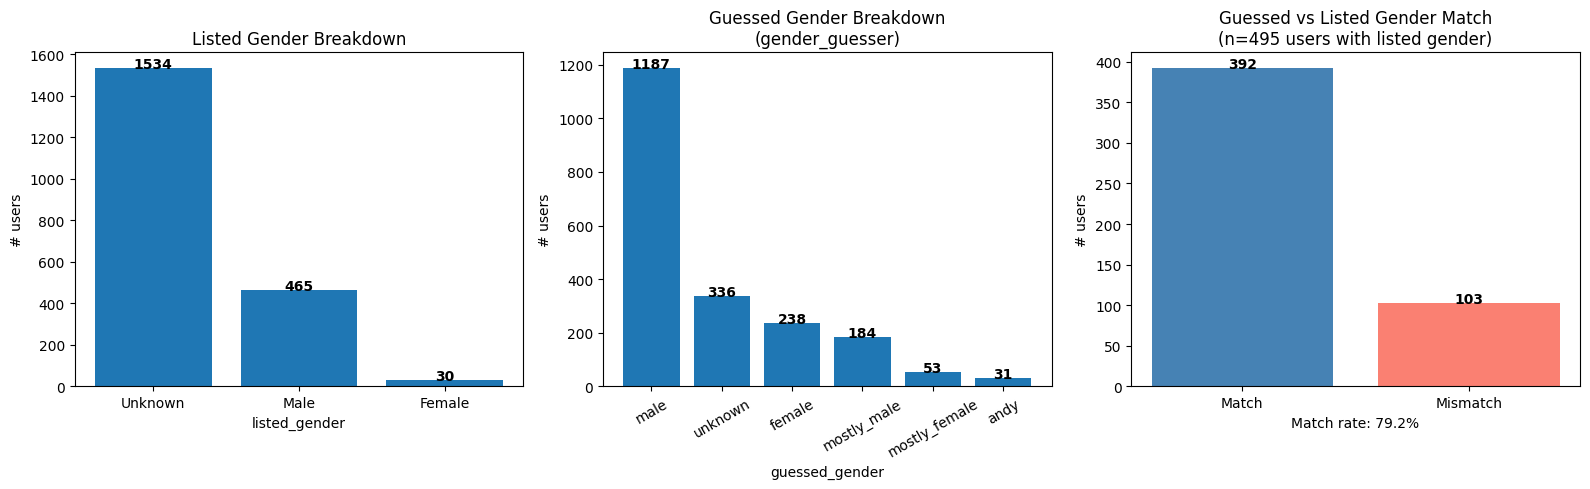

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: listed_gender breakdown ---
listed_counts = user_info_df['listed_gender'].fillna('Unknown').value_counts()
axes[0].bar(listed_counts.index, listed_counts.values)
axes[0].set_title('Listed Gender Breakdown')
axes[0].set_xlabel('listed_gender')
axes[0].set_ylabel('# users')
for i, v in enumerate(listed_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# --- Plot 2: guessed_gender breakdown ---
guessed_counts = user_info_df['guessed_gender'].fillna('unknown').value_counts()
axes[1].bar(guessed_counts.index, guessed_counts.values)
axes[1].set_title('Guessed Gender Breakdown\n(gender_guesser)')
axes[1].set_xlabel('guessed_gender')
axes[1].set_ylabel('# users')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(guessed_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# --- Plot 3: guessed vs listed match rate ---
# Only compare users who have a listed gender
has_listed = user_info_df.dropna(subset=['listed_gender', 'guessed_gender']).copy()

# Normalize: map guessed_gender to Male/Female for comparison
guess_map = {
    'male': 'Male', 'mostly_male': 'Male',
    'female': 'Female', 'mostly_female': 'Female',
    'andy': 'Unknown', 'unknown': 'Unknown'
}
has_listed['guessed_normalized'] = has_listed['guessed_gender'].map(guess_map).fillna('Unknown')
has_listed['match'] = has_listed['listed_gender'] == has_listed['guessed_normalized']

match_counts = has_listed['match'].value_counts()
match_labels = ['Match' if k else 'Mismatch' for k in match_counts.index]
axes[2].bar(match_labels, match_counts.values, color=['steelblue', 'salmon'])
axes[2].set_title(f'Guessed vs Listed Gender Match\n(n={len(has_listed)} users with listed gender)')
axes[2].set_ylabel('# users')
for i, v in enumerate(match_counts.values):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

match_rate = has_listed['match'].mean()
axes[2].set_xlabel(f'Match rate: {match_rate:.1%}')

plt.tight_layout()
plt.show()

In [126]:
user_info_df['listed_gender'].value_counts()

listed_gender
Male      465
Female     30
Name: count, dtype: int64

In [127]:
user_info_df['guessed_gender'].value_counts()

guessed_gender
male             1187
unknown           336
female            238
mostly_male       184
mostly_female      53
andy               31
Name: count, dtype: int64

In [129]:
area_df = area_df.merge(
    user_info_df[['user_ID', 'user_URL', 'location', 'age_at_request_date', 'listed_gender', 'guessed_gender']],
    left_on='user.id',
    right_on='user_ID',
    how='left'
).drop(columns='user_ID')

area_df.head()

,Route,Location,URL,Avg Stars,Your Stars,Route Type,Rating,Pitches,Length,Area Latitude,...,style,leadStyle,pitches,tick_createdAt,tick_updatedAt,user_URL,location,age_at_request_date,listed_gender,guessed_gender
0,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,,,1.0,2025-04-09T04:29:09.000000Z,2025-04-09T04:29:09.000000Z,https://www.mountainproject.com/user/10795/cra...,"Louisville, CO",NaN,Male,male
1,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,Attempt,,1.0,2023-04-02T23:11:53.000000Z,2023-04-02T23:11:53.000000Z,https://www.mountainproject.com/user/10795/cra...,"Louisville, CO",NaN,Male,male
2,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,Lead,Onsight,1.0,2021-03-31T00:57:57.000000Z,2021-03-31T00:57:57.000000Z,https://www.mountainproject.com/user/105841142...,michigan,48.0,Male,unknown
3,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,,,1.0,2019-05-16T18:55:03.000000Z,2019-05-16T18:55:03.000000Z,https://www.mountainproject.com/user/106196136...,None,NaN,None,male
4,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,NaN,NaN,NaN,NaN,NaN,https://www.mountainproject.com/user/106201630...,"Moab, UT",41.0,Male,male


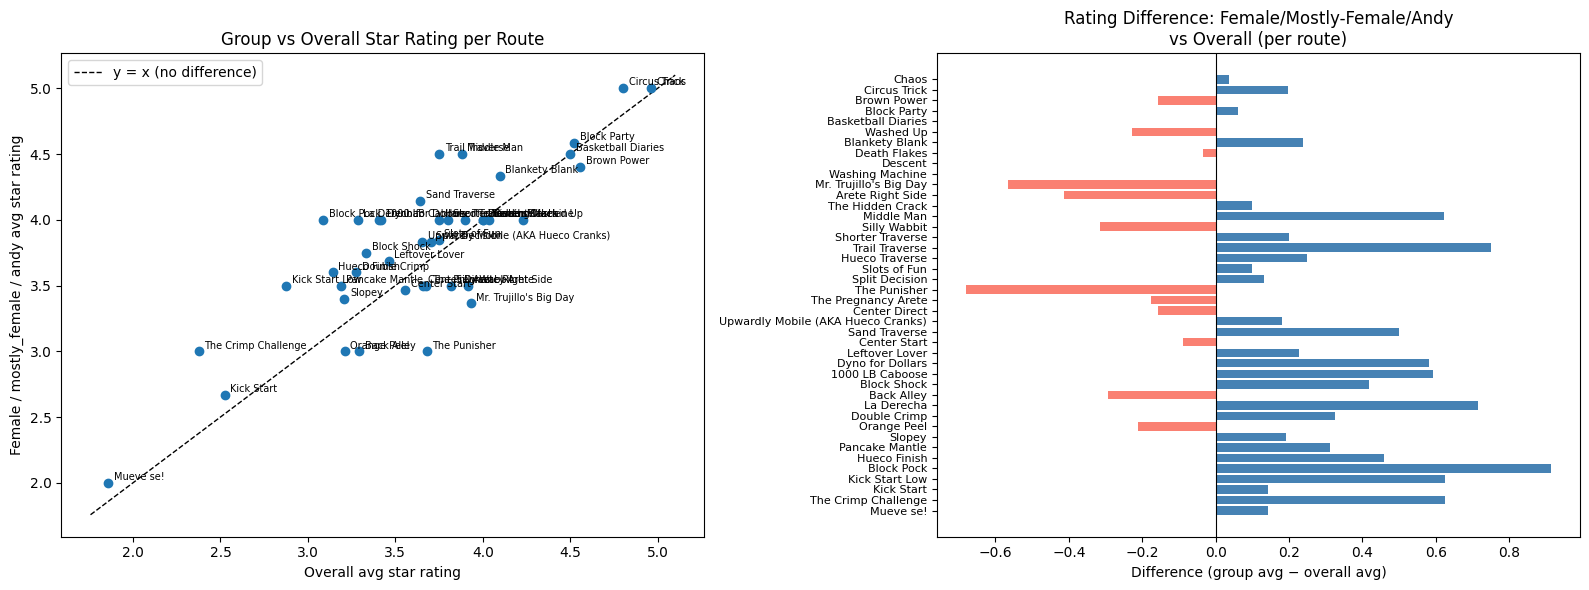

                                    overall_avg  group_avg  diff
Route                                                           
Mueve se!                                  1.86       2.00  0.14
The Crimp Challenge                        2.38       3.00  0.62
Kick Start                                 2.53       2.67  0.14
Kick Start Low                             2.88       3.50  0.62
Block Pock                                 3.09       4.00  0.91
Hueco Finish                               3.14       3.60  0.46
Pancake Mantle                             3.19       3.50  0.31
Slopey                                     3.21       3.40  0.19
Orange Peel                                3.21       3.00 -0.21
Double Crimp                               3.28       3.60  0.32
La Derecha                                 3.29       4.00  0.71
Back Alley                                 3.29       3.00 -0.29
Block Shock                                3.33       3.75  0.42
1000 LB Caboose          

In [130]:


target_genders = ['female', 'mostly_female', 'andy']
male_genders = ['male', 'mostly_male']

# Only include routes with >= 3 female and >= 3 male ratings
female_counts = area_df[area_df['guessed_gender'].isin(target_genders)].groupby('Route')['score'].count()
male_counts = area_df[area_df['guessed_gender'].isin(male_genders)].groupby('Route')['score'].count()
qualified_routes = female_counts[female_counts >= 3].index.intersection(male_counts[male_counts >= 3].index)
print(f"{len(qualified_routes)} routes meet the minimum rating threshold (>=3 female, >=3 male)")

# Per-route averages (qualified routes only)
overall_avg = area_df[area_df['Route'].isin(qualified_routes)].groupby('Route')['score'].mean().rename('overall_avg')
group_avg = (
    area_df[area_df['guessed_gender'].isin(target_genders) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('group_avg')
)

compare_df = pd.concat([overall_avg, group_avg], axis=1).dropna()
compare_df['diff'] = compare_df['group_avg'] - compare_df['overall_avg']
compare_df = compare_df.sort_values('overall_avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter — group avg vs overall avg per route ---
ax = axes[0]
ax.scatter(compare_df['overall_avg'], compare_df['group_avg'], zorder=3)
lims = [
    min(compare_df['overall_avg'].min(), compare_df['group_avg'].min()) - 0.1,
    max(compare_df['overall_avg'].max(), compare_df['group_avg'].max()) + 0.1,
]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (no difference)')
for route, row in compare_df.iterrows():
    ax.annotate(route, (row['overall_avg'], row['group_avg']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))
ax.set_xlabel('Overall avg star rating')
ax.set_ylabel('Female / mostly_female / andy avg star rating')
ax.set_title('Group vs Overall Star Rating per Route')
ax.legend()

# --- Plot 2: Difference bar chart (group_avg - overall_avg) ---
ax = axes[1]
colors = ['salmon' if d < 0 else 'steelblue' for d in compare_df['diff']]
bars = ax.barh(compare_df.index, compare_df['diff'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (group avg − overall avg)')
ax.set_title('Rating Difference: Female/Mostly-Female/Andy\nvs Overall (per route)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(compare_df[['overall_avg', 'group_avg', 'diff']].round(2))

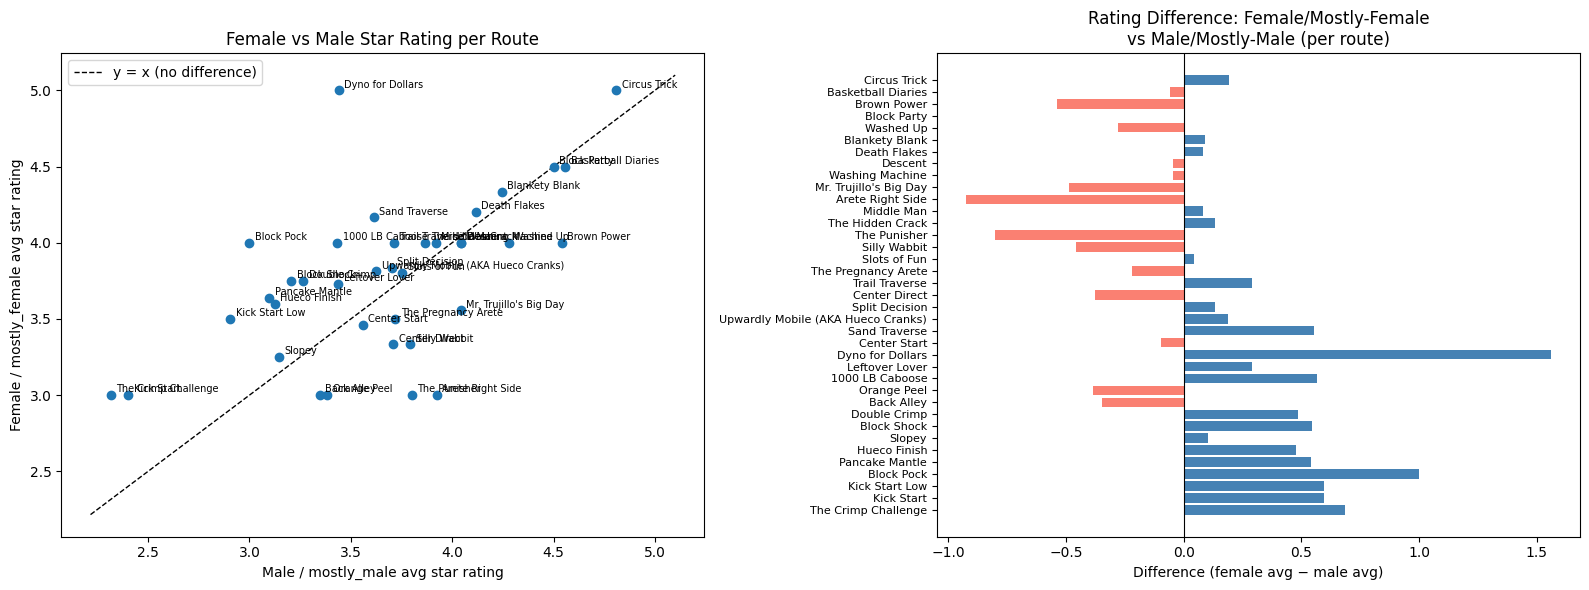

                                    female_avg  male_avg  diff
Route                                                         
The Crimp Challenge                       3.00      2.32  0.68
Kick Start                                3.00      2.40  0.60
Kick Start Low                            3.50      2.91  0.59
Block Pock                                4.00      3.00  1.00
Pancake Mantle                            3.64      3.10  0.54
Hueco Finish                              3.60      3.12  0.48
Slopey                                    3.25      3.15  0.10
Block Shock                               3.75      3.21  0.54
Double Crimp                              3.75      3.26  0.49
Back Alley                                3.00      3.35 -0.35
Orange Peel                               3.00      3.38 -0.38
1000 LB Caboose                           4.00      3.43  0.57
Leftover Lover                            3.73      3.44  0.29
Dyno for Dollars                          5.00      3.4

In [ ]:
# Only include routes with >= 3 female and >= 3 male ratings
female_counts = area_df[area_df['guessed_gender'].isin(['female', 'mostly_female'])].groupby('Route')['score'].count()
male_counts = area_df[area_df['guessed_gender'].isin(['male', 'mostly_male'])].groupby('Route')['score'].count()
qualified_routes = female_counts[female_counts >= 3].index.intersection(male_counts[male_counts >= 3].index)
print(f"{len(qualified_routes)} routes meet the minimum rating threshold (>=3 female, >=3 male)")

female_avg = (
    area_df[area_df['guessed_gender'].isin(['female', 'mostly_female']) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('female_avg')
)
male_avg = (
    area_df[area_df['guessed_gender'].isin(['male', 'mostly_male']) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('male_avg')
)

fm_df = pd.concat([female_avg, male_avg], axis=1).dropna()
fm_df['diff'] = fm_df['female_avg'] - fm_df['male_avg']
fm_df = fm_df.sort_values('male_avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter ---
ax = axes[0]
ax.scatter(fm_df['male_avg'], fm_df['female_avg'], zorder=3)
lims = [
    min(fm_df['male_avg'].min(), fm_df['female_avg'].min()) - 0.1,
    max(fm_df['male_avg'].max(), fm_df['female_avg'].max()) + 0.1,
]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (no difference)')
for route, row in fm_df.iterrows():
    ax.annotate(route, (row['male_avg'], row['female_avg']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))
ax.set_xlabel('Male / mostly_male avg star rating')
ax.set_ylabel('Female / mostly_female avg star rating')
ax.set_title('Female vs Male Star Rating per Route')
ax.legend()

# --- Plot 2: Difference bar chart (female_avg - male_avg) ---
ax = axes[1]
colors = ['salmon' if d < 0 else 'steelblue' for d in fm_df['diff']]
ax.barh(fm_df.index, fm_df['diff'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (female avg − male avg)')
ax.set_title('Rating Difference: Female/Mostly-Female\nvs Male/Mostly-Male (per route)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(fm_df[['female_avg', 'male_avg', 'diff']].round(2))